In [11]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# ---- config ----
# Pool multiple files by listing them all — combines context bins or needle counts.
PROBE_PATHS = [
    "/c2/jenny/r3/MRCR_outputs/probe_layer_8needle_16-32k.jsonl",
]

# Spearman rho threshold.  With N=100, rho≈0.20 is ~p<0.05 (two-tailed).
# Lower this if N is small and you want to see weak signals too.
SPEARMAN_THRESHOLD = 0.20
TOP_K    = 6      # top heads shown in trace alignment
MRCR_PASS = 0.5   # threshold for binary pass/fail label (traces only)

CTX_LABEL = os.path.splitext(os.path.basename(PROBE_PATHS[-1]))[0][-6:]
if len(PROBE_PATHS) > 1:
    CTX_LABEL = f"pooled_{len(PROBE_PATHS)}files"
print(f"label: {CTX_LABEL}")

label: 16-32k


In [12]:
# ---- load and pool ----
records = []
for path in PROBE_PATHS:
    n_before = len(records)
    with open(path) as f:
        for line in f:
            records.append(json.loads(line))
    print(f"{os.path.basename(path)}: +{len(records) - n_before}")

valid = [r for r in records if r.get("attn_entropy_per_layer")]
print(f"\ntotal={len(records)}  with per-layer data={len(valid)}")

# which layer indices actually have data (reveals hybrid-attn architecture)
layer_keys = sorted({int(k)
                     for r in valid
                     for k in r["attn_entropy_per_layer"]})
n_logged_layers = len(layer_keys)
n_layers_full   = max(layer_keys) + 1   # span including gaps
sample_steps    = valid[0]["attn_entropy_per_layer"][str(layer_keys[0])]
n_heads         = len(sample_steps[0])
print(f"Layer indices with data ({n_logged_layers} total): {layer_keys}")
print(f"n_heads={n_heads}")
print(f"NOTE: if fewer than all layers have data, the model uses hybrid "
      f"(sliding-window + full) attention; only full-attention layers log.")

y_score  = np.array([r["mrcr_score"] for r in valid])
y_binary = (y_score >= MRCR_PASS).astype(int)
print(f"\nmrcr_score  mean={y_score.mean():.3f}  std={y_score.std():.3f}")
print(f"pass rate:  {y_binary.mean()*100:.1f}%  ({y_binary.sum()}/{len(valid)})")
print(f"score deciles: {np.round(np.percentile(y_score, np.arange(0,101,10)), 3)}")

probe_layer_8needle_16-32k.jsonl: +100

total=100  with per-layer data=100
Layer indices with data (8 total): [3, 7, 11, 15, 19, 23, 27, 31]
n_heads=16
NOTE: if fewer than all layers have data, the model uses hybrid (sliding-window + full) attention; only full-attention layers log.

mrcr_score  mean=0.527  std=0.458
pass rate:  48.0%  (48/100)
score deciles: [0.013 0.031 0.049 0.066 0.106 0.319 0.998 1.    1.    1.    1.   ]


In [13]:
# ---- build feature matrices (logged layers only) ----
# X_mean[i, li_idx, hi]  = mean norm-attn-entropy over logged steps
# X_step0[i, li_idx, hi] = norm-attn-entropy at decode step 0
# li_idx is position in layer_keys list, not the raw layer index.

N = len(valid)
L = n_logged_layers
H = n_heads

X_mean  = np.full((N, L, H), np.nan)
X_step0 = np.full((N, L, H), np.nan)

layer_key_to_idx = {k: i for i, k in enumerate(layer_keys)}

for i, r in enumerate(valid):
    for li_str, steps in r["attn_entropy_per_layer"].items():
        li = int(li_str)
        li_idx = layer_key_to_idx.get(li)
        if li_idx is None or not steps:
            continue
        arr = np.array(steps)   # [T, H]
        X_mean[i, li_idx, :]  = arr.mean(axis=0)
        X_step0[i, li_idx, :] = arr[0]

nan_frac = np.isnan(X_mean).mean()
print(f"X shape: {X_mean.shape}  NaN fraction: {nan_frac:.4f}  "
      f"(expected ~0 if all layers logged)")

X shape: (100, 8, 16)  NaN fraction: 0.0000  (expected ~0 if all layers logged)


In [14]:
# ---- compute Spearman rho grids ----
# Higher attention entropy -> confused -> predicts lower mrcr_score.
# We pass -entropy so positive rho means head is predictive of failure.

def compute_spearman_grid(X, y_cont, min_samples=10):
    """X: [N, L, H], y_cont: continuous [N] -> rho grid [L, H], pval grid [L, H]."""
    L, H = X.shape[1], X.shape[2]
    rho_grid  = np.full((L, H), 0.0)
    pval_grid = np.full((L, H), 1.0)
    for li in range(L):
        for hi in range(H):
            scores = X[:, li, hi]
            ok = ~np.isnan(scores)
            if ok.sum() < min_samples:
                continue
            try:
                rho, pval = spearmanr(-scores[ok], y_cont[ok])
                rho_grid[li, hi]  = rho
                pval_grid[li, hi] = pval
            except Exception:
                pass
    return rho_grid, pval_grid

rho_mean,  pval_mean  = compute_spearman_grid(X_mean,  y_score)
rho_step0, pval_step0 = compute_spearman_grid(X_step0, y_score)

print(f"Full-trace  max={rho_mean.max():.3f}  mean={rho_mean.mean():.3f}  "
      f"rho>={SPEARMAN_THRESHOLD}: {(rho_mean >= SPEARMAN_THRESHOLD).sum()}  "
      f"p<0.05: {(pval_mean < 0.05).sum()}")
print(f"Step-0      max={rho_step0.max():.3f}  mean={rho_step0.mean():.3f}  "
      f"rho>={SPEARMAN_THRESHOLD}: {(rho_step0 >= SPEARMAN_THRESHOLD).sum()}  "
      f"p<0.05: {(pval_step0 < 0.05).sum()}")

Full-trace  max=0.271  mean=-0.043  rho>=0.2: 1  p<0.05: 17
Step-0      max=0.254  mean=-0.023  rho>=0.2: 7  p<0.05: 21


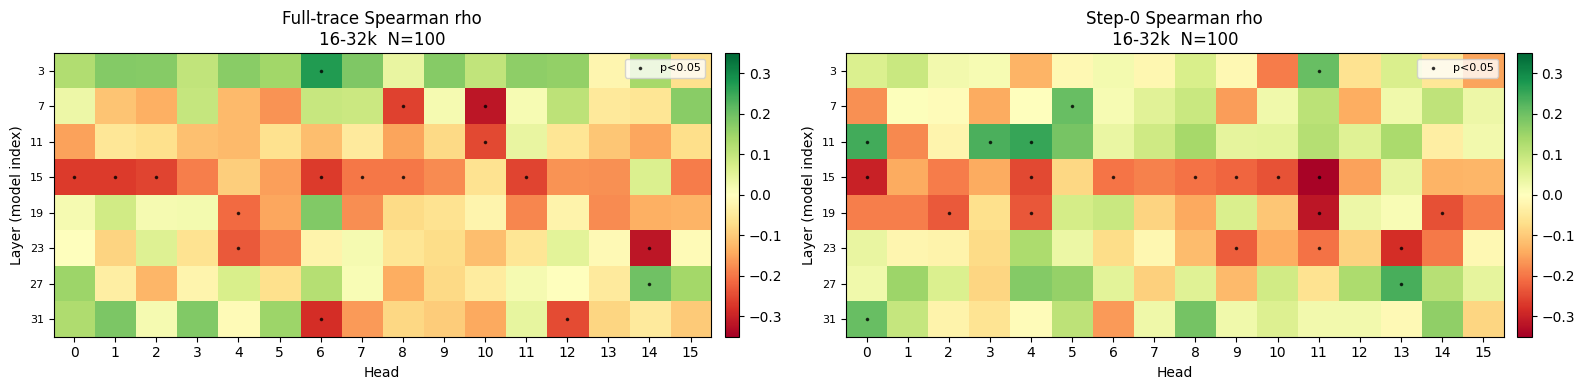

In [15]:
# ---- Spearman heatmaps: full-trace vs step-0 ----
# Y-axis = logged layer index (0 = first full-attn layer in the model)
# Black dots = p < 0.05

fig, axes = plt.subplots(1, 2, figsize=(16, max(4, n_logged_layers // 2)))

ytick_labels = [str(k) for k in layer_keys]

for ax, grid, pvals, title in zip(
    axes,
    [rho_mean, rho_step0],
    [pval_mean, pval_step0],
    ["Full-trace Spearman rho", "Step-0 Spearman rho"],
):
    im = ax.imshow(grid, vmin=-0.35, vmax=0.35,
                   cmap="RdYlGn", aspect="auto", origin="upper")
    ys, xs = np.where(pvals < 0.05)
    ax.scatter(xs, ys, marker=".", s=10, color="black", alpha=0.7, label="p<0.05")
    ax.set_xticks(range(H))
    ax.set_yticks(range(L))
    ax.set_yticklabels(ytick_labels, fontsize=8)
    ax.set_xlabel("Head")
    ax.set_ylabel("Layer (model index)")
    ax.set_title(f"{title}\n{CTX_LABEL}  N={len(valid)}")
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    ax.legend(fontsize=8, loc="upper right")

plt.tight_layout()
plt.savefig(f"spearman_heatmap_{CTX_LABEL}.png", dpi=120, bbox_inches="tight")
plt.show()

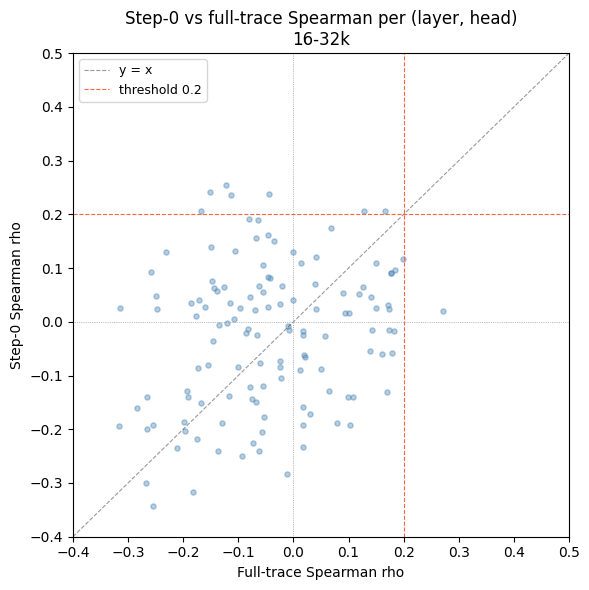

In [16]:
# ---- step-0 vs full-trace Spearman scatter ----
# Above diagonal: signal present at step-0 (commits early)
# Below diagonal: signal develops later in generation

fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(rho_mean.ravel(), rho_step0.ravel(),
           alpha=0.4, s=14, color="steelblue")
lims = [-0.40, 0.50]
ax.plot(lims, lims, "k--", lw=0.8, alpha=0.4, label="y = x")
ax.axhline(SPEARMAN_THRESHOLD, color="tomato", lw=0.8, ls="--",
           label=f"threshold {SPEARMAN_THRESHOLD}")
ax.axvline(SPEARMAN_THRESHOLD, color="tomato", lw=0.8, ls="--")
ax.axhline(0, color="gray", lw=0.5, ls=":")
ax.axvline(0, color="gray", lw=0.5, ls=":")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Full-trace Spearman rho")
ax.set_ylabel("Step-0 Spearman rho")
ax.set_title(f"Step-0 vs full-trace Spearman per (layer, head)\n{CTX_LABEL}")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f"spearman_scatter_{CTX_LABEL}.png", dpi=120, bbox_inches="tight")
plt.show()

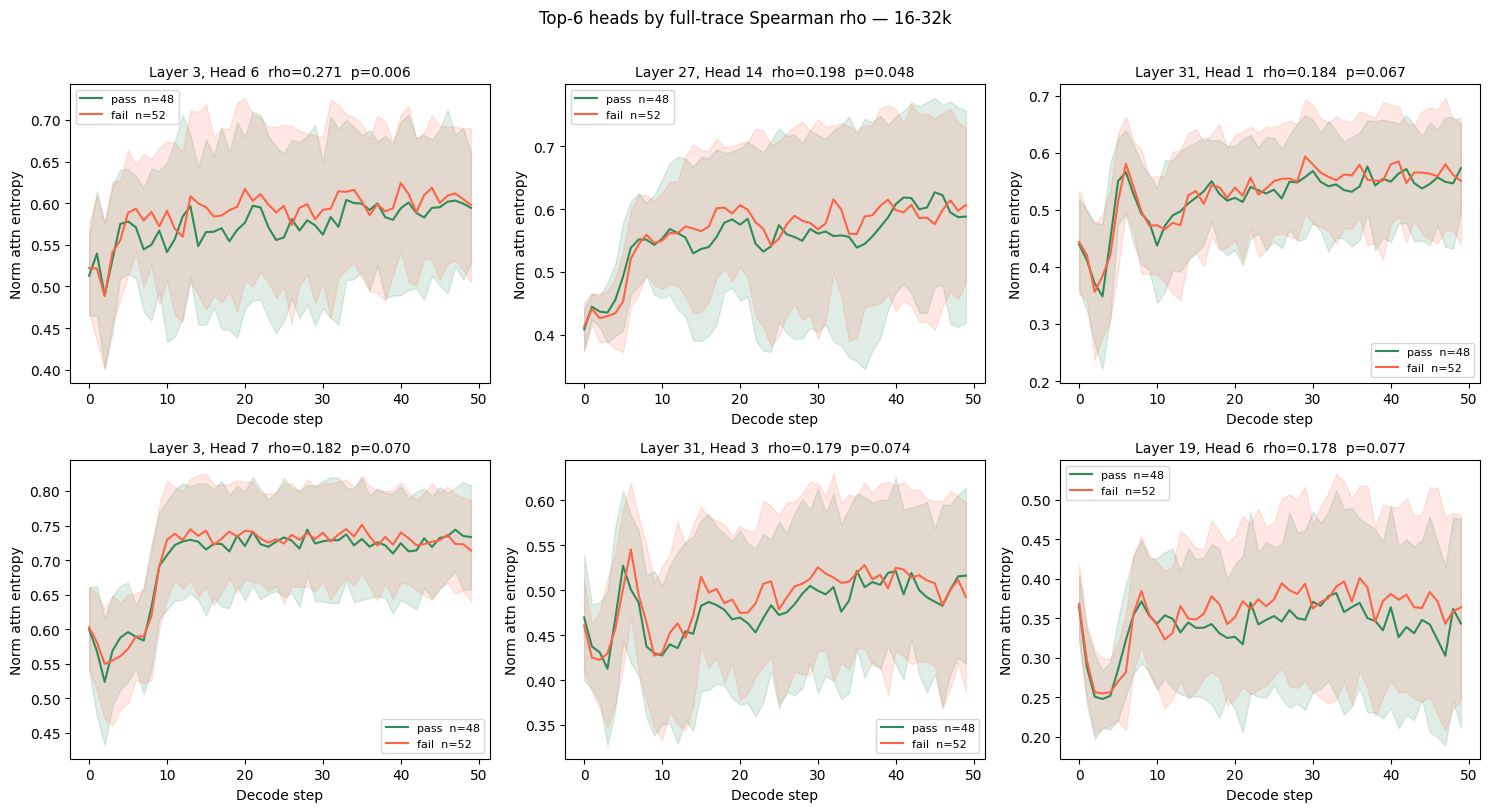

In [17]:
# ---- top-K heads: entropy trace alignment (pass vs fail) ----
top_flat  = np.argsort(rho_mean.ravel())[::-1][:TOP_K]
top_heads = [(layer_keys[idx // H], idx % H) for idx in top_flat]  # (model_layer_idx, head)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for ax, (li, hi) in zip(axes, top_heads):
    pos_traces, neg_traces = [], []
    for i, r in enumerate(valid):
        steps = r["attn_entropy_per_layer"].get(str(li), [])
        if not steps:
            continue
        trace = np.array(steps)[:, hi]
        (pos_traces if y_binary[i] == 1 else neg_traces).append(trace)

    def _plot(ax, traces, color, label):
        if not traces:
            return
        T = min(len(t) for t in traces)
        mat = np.array([t[:T] for t in traces])
        m, s = mat.mean(0), mat.std(0)
        x = np.arange(T)
        ax.plot(x, m, color=color, label=label, lw=1.5)
        ax.fill_between(x, m - s, m + s, color=color, alpha=0.15)

    _plot(ax, pos_traces, "seagreen", f"pass  n={len(pos_traces)}")
    _plot(ax, neg_traces, "tomato",   f"fail  n={len(neg_traces)}")
    li_idx = layer_key_to_idx[li]
    rho_v  = rho_mean[li_idx, hi]
    pval_v = pval_mean[li_idx, hi]
    ax.set_title(f"Layer {li}, Head {hi}  rho={rho_v:.3f}  p={pval_v:.3f}", fontsize=10)
    ax.set_xlabel("Decode step")
    ax.set_ylabel("Norm attn entropy")
    ax.legend(fontsize=8)

plt.suptitle(f"Top-{TOP_K} heads by full-trace Spearman rho — {CTX_LABEL}", y=1.01)
plt.tight_layout()
plt.savefig(f"top_heads_traces_{CTX_LABEL}.png", dpi=120, bbox_inches="tight")
plt.show()

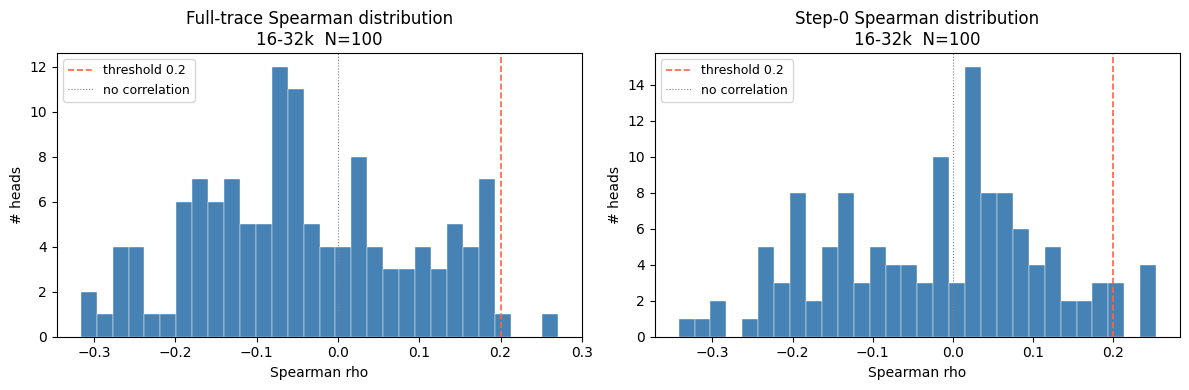

In [18]:
# ---- Spearman rho distribution across heads ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, grid, label in zip(axes,
                            [rho_mean, rho_step0],
                            ["Full-trace", "Step-0"]):
    ax.hist(grid.ravel(), bins=30, color="steelblue",
            edgecolor="white", lw=0.3)
    ax.axvline(SPEARMAN_THRESHOLD, color="tomato", lw=1.2, ls="--",
               label=f"threshold {SPEARMAN_THRESHOLD}")
    ax.axvline(0, color="gray", lw=0.8, ls=":", label="no correlation")
    ax.set_xlabel("Spearman rho")
    ax.set_ylabel("# heads")
    ax.set_title(f"{label} Spearman distribution\n{CTX_LABEL}  N={len(valid)}")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f"spearman_distribution_{CTX_LABEL}.png", dpi=120, bbox_inches="tight")
plt.show()

In [19]:
# ---- retrieval head table + save mask ----
# Mask shape matches logged layers only: [n_logged_layers, n_heads]
retrieval_mask = rho_mean >= SPEARMAN_THRESHOLD
print(f"Retrieval heads (rho >= {SPEARMAN_THRESHOLD}): "
      f"{retrieval_mask.sum()} / {L * H}")
print()
print(f"{'ModelLayer':>11}  {'Head':>5}  {'rho_full':>9}  "
      f"{'rho_step0':>10}  {'p_full':>7}  {'commits_early':>13}")
print("-" * 65)
for li_idx, hi in sorted(
    zip(*np.where(retrieval_mask)),
    key=lambda x: -rho_mean[x[0], x[1]]
):
    li = layer_keys[li_idx]
    early = rho_step0[li_idx, hi] >= SPEARMAN_THRESHOLD
    print(f"{li:>11}  {hi:>5}  {rho_mean[li_idx,hi]:>9.3f}  "
          f"{rho_step0[li_idx,hi]:>10.3f}  "
          f"{pval_mean[li_idx,hi]:>7.3f}  "
          f"{'yes' if early else 'no':>13}")

mask_path = PROBE_PATHS[-1].replace(".jsonl", "_retrieval_mask.npy")
np.save(mask_path, retrieval_mask)
print(f"\nMask shape: {retrieval_mask.shape}  (logged layers x heads)")
print(f"Layer index mapping: {dict(enumerate(layer_keys))}")
print(f"Saved: {mask_path}")

Retrieval heads (rho >= 0.2): 1 / 128

 ModelLayer   Head   rho_full   rho_step0   p_full  commits_early
-----------------------------------------------------------------
          3      6      0.271       0.020    0.006             no

Mask shape: (8, 16)  (logged layers x heads)
Layer index mapping: {0: 3, 1: 7, 2: 11, 3: 15, 4: 19, 5: 23, 6: 27, 7: 31}
Saved: /c2/jenny/r3/MRCR_outputs/probe_layer_8needle_16-32k_retrieval_mask.npy
